In [54]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

import processing as proc
import metricas
import dataset

In [ ]:
## Funcoes Aux




(<PIL.Image.Image image mode=RGB size=64x64 at 0x7FC3022875C0>, array([3]))
No module named 'pyopencl'
No module named 'pyopencl'
---------------
[[193 211 223 ... 224 225 225]
 [188 203 221 ... 224 225 225]
 [185 196 218 ... 224 225 224]
 ...
 [142 141 140 ... 223 223 223]
 [143 141 141 ... 224 224 224]
 [147 144 142 ... 222 224 224]]
[[137 163 157 ... 167 178 202]
 [ 99 186 195 ... 255 215 235]
 [112 165 192 ... 204 253 168]
 ...
 [ 74 106  99 ... 253 180 255]
 [103 114  79 ... 195 247 176]
 [ 99 103  73 ... 192 157 192]]
---------------


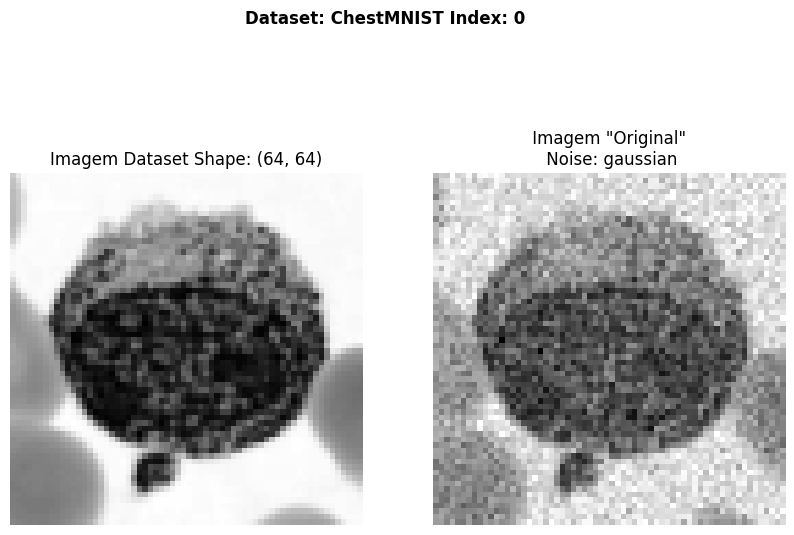

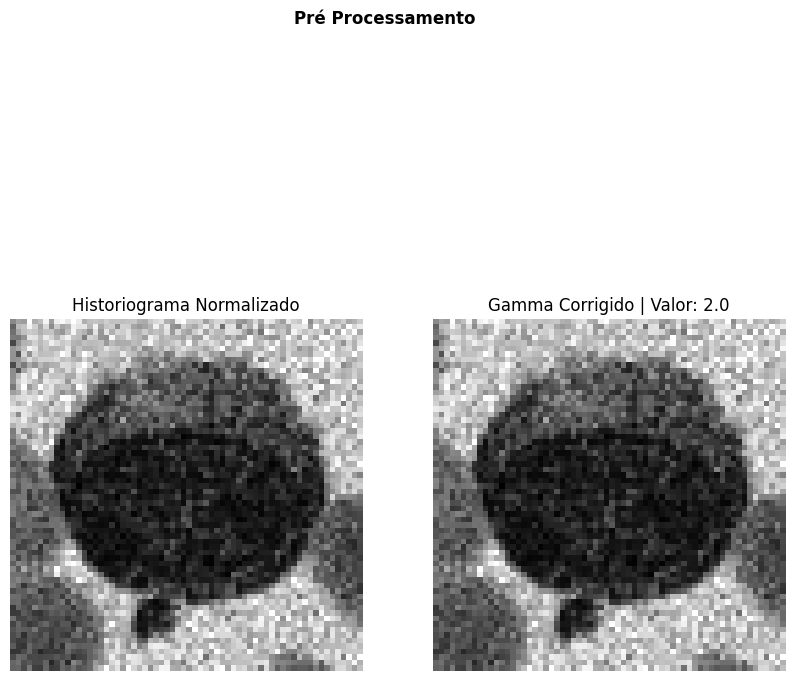

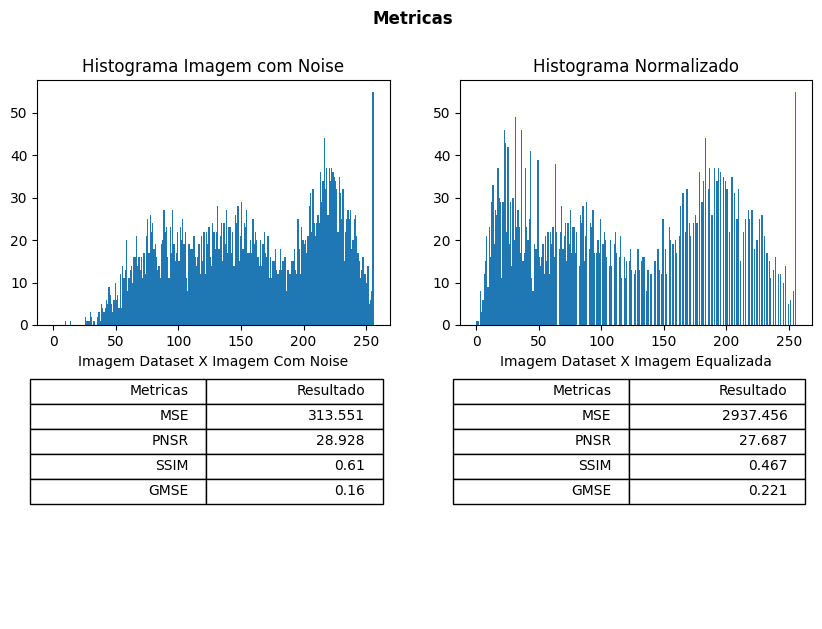

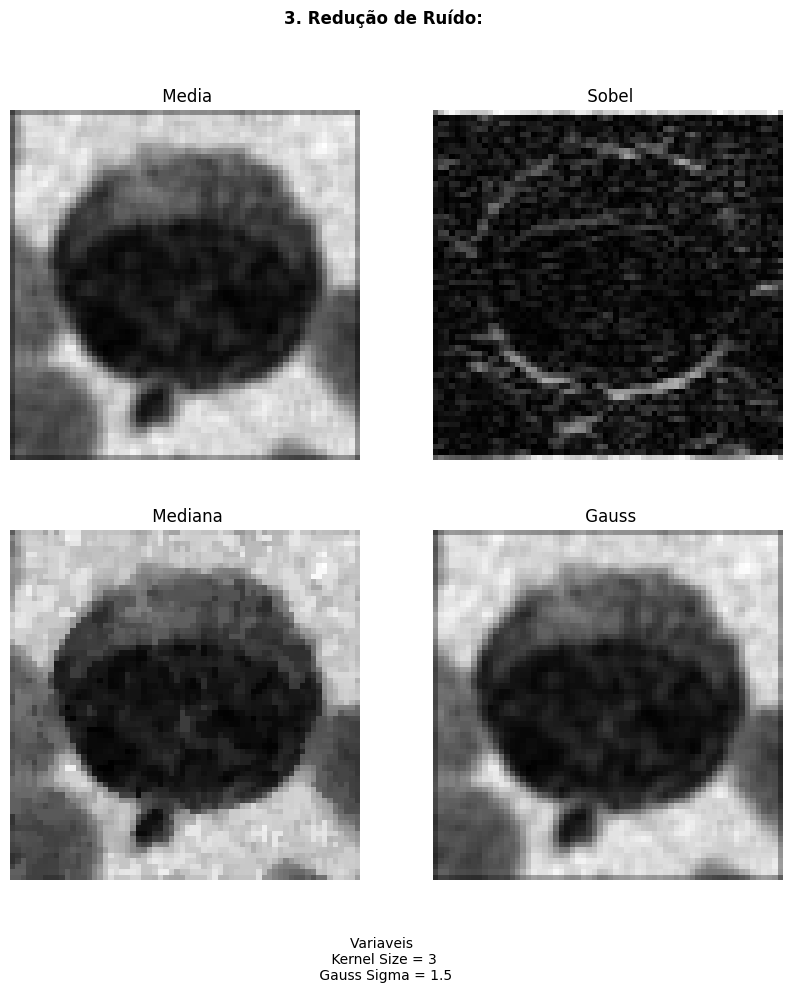

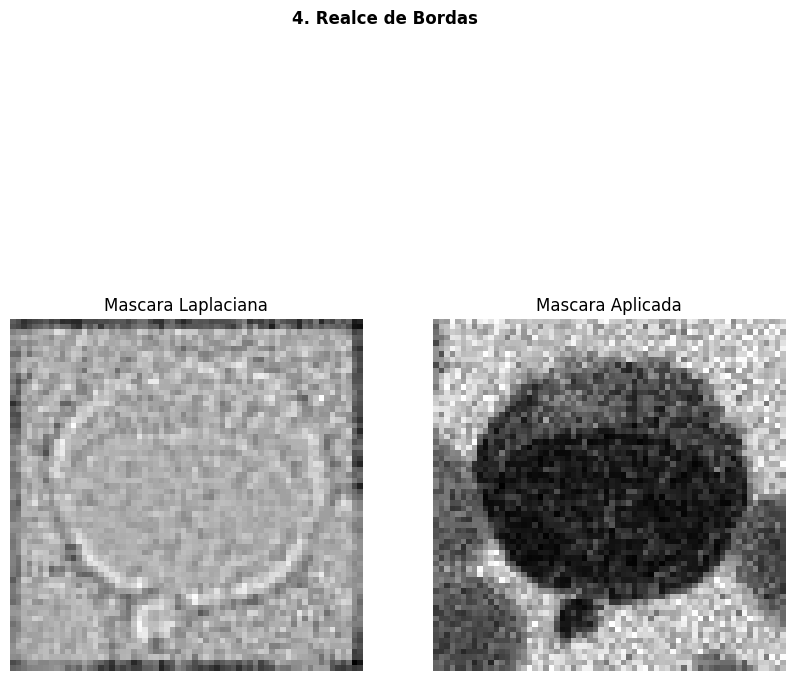

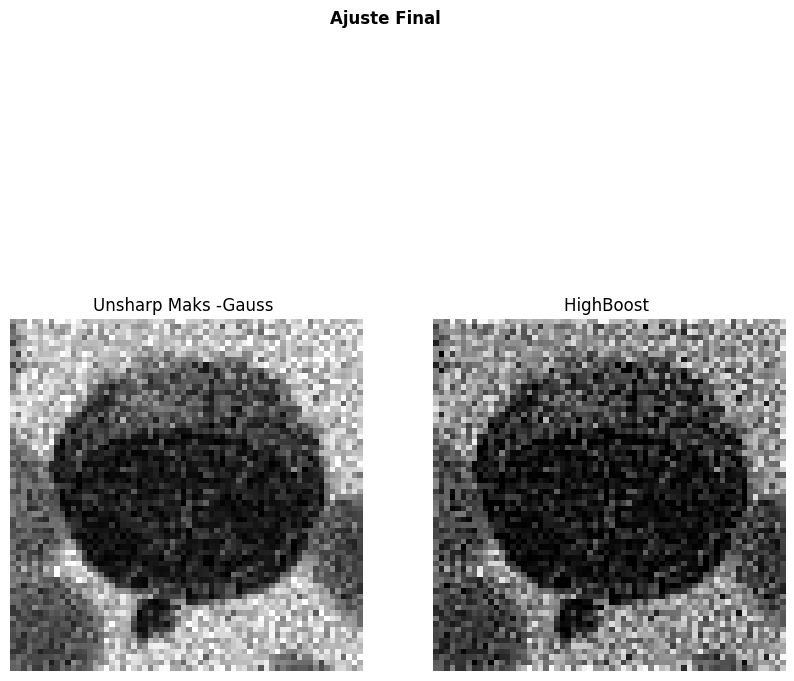

No module named 'pyopencl'
No module named 'pyopencl'
---------------
[[223 222 217 ... 174 176 174]
 [217 222 218 ... 184 185 183]
 [201 218 221 ... 199 196 192]
 ...
 [163 166 168 ... 158 159 158]
 [163 165 167 ... 155 157 156]
 [163 166 168 ... 157 157 158]]
[[202 157 176 ... 148 127  91]
 [160 208 171 ... 103 130 129]
 [195 202 224 ... 162 116 151]
 ...
 [110 112  90 ...  84  90 115]
 [106  92 136 ...  66 110 112]
 [127  91  94 ...  83 132 132]]
---------------


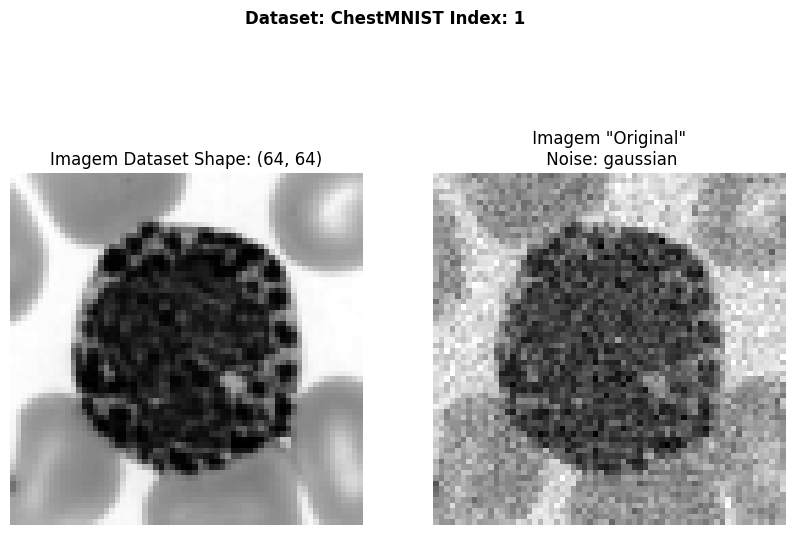

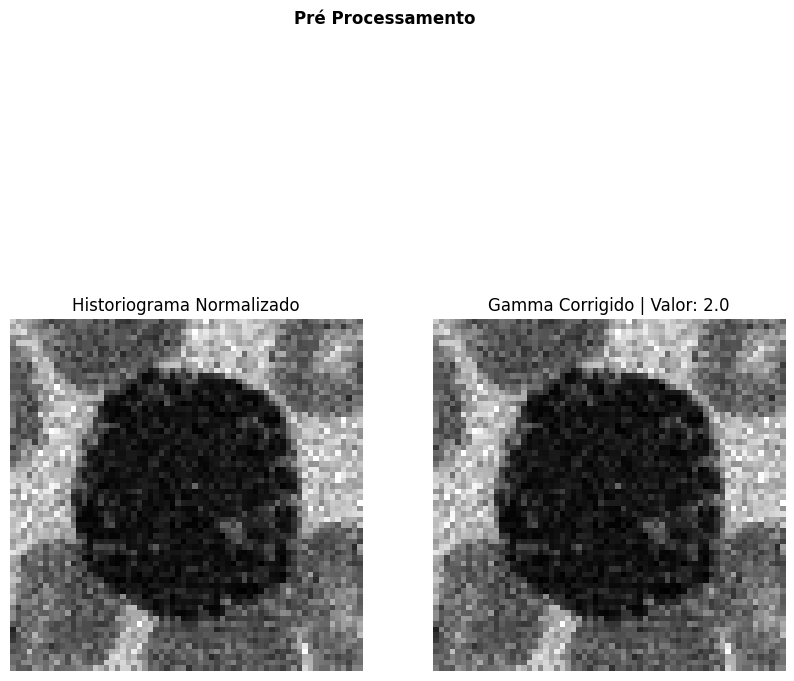

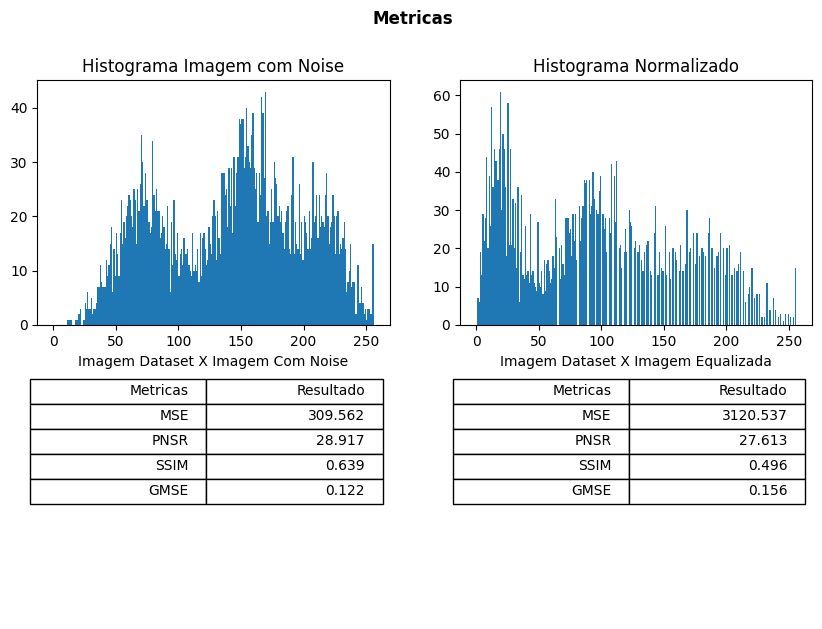

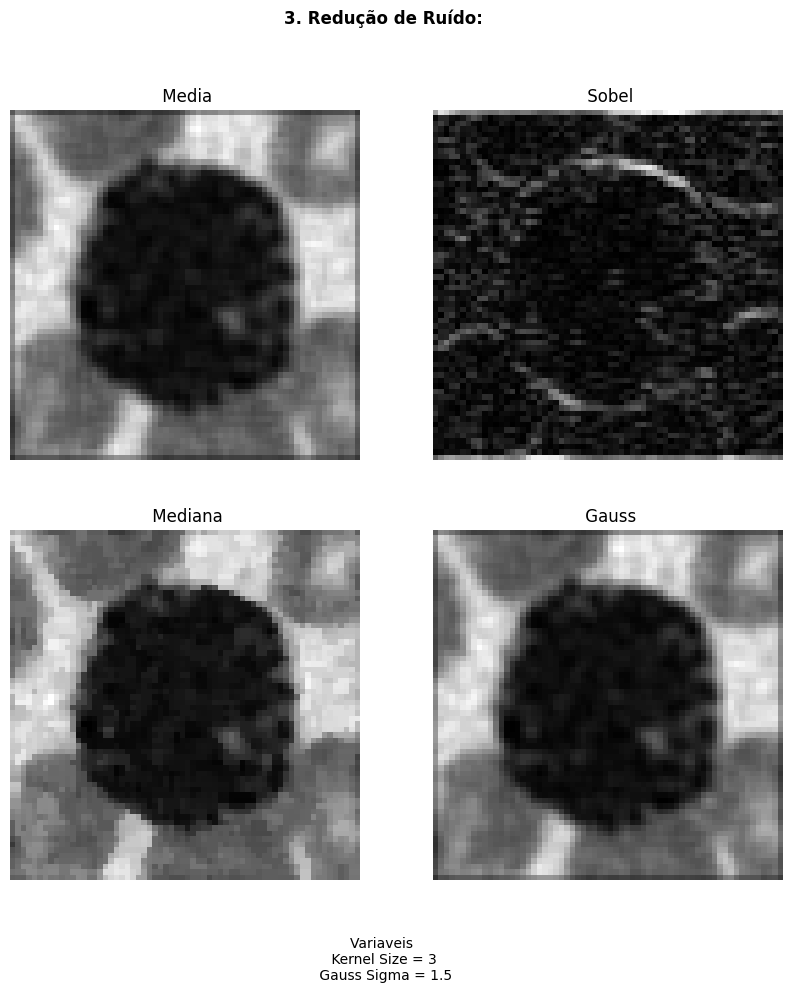

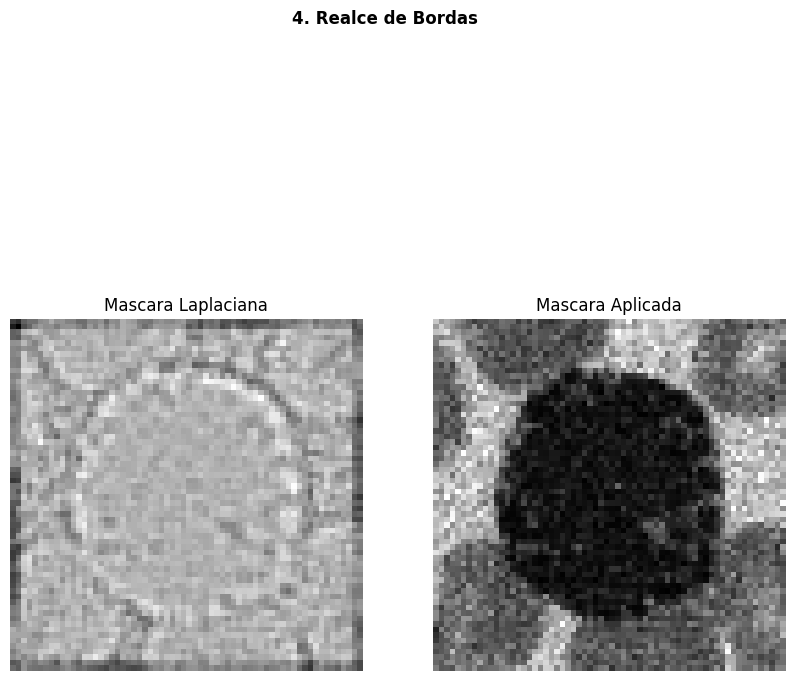

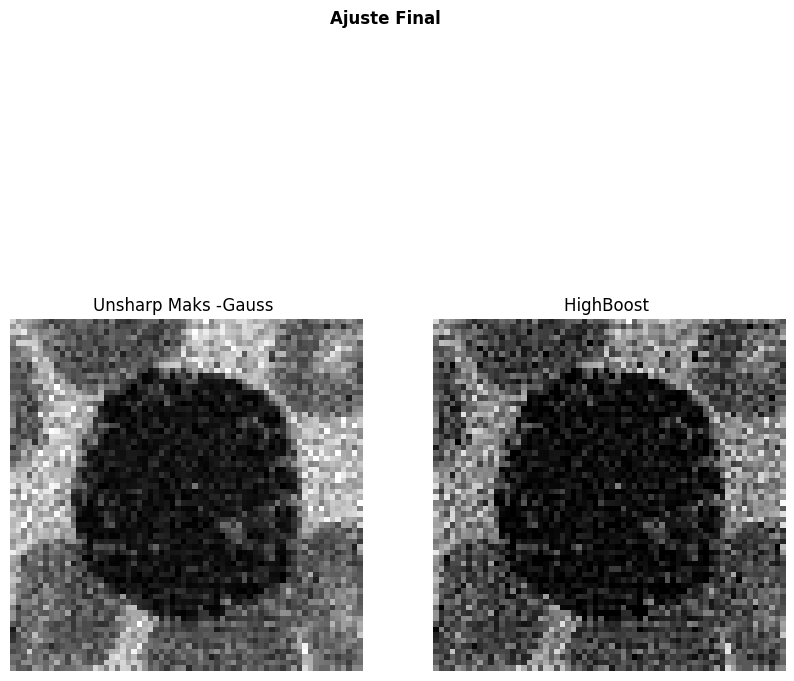

In [148]:
##
raw_ds = dataset.create_dataset(2, False)
## Noise
modes = [
    "gaussian", 
    "speckle"
]
noise_mode = modes[0]
## Variaveis de Processamento
var_gamma = 2.0
var_k_size = 3
var_gauss_sigma = 1.5
var_f_unsharp = 0.2
var_f_highboost =  1.2


for i in range(len(raw_ds)):
    idx, raw_img = raw_ds[i]
    img = proc.prep_img(raw_img)
    n_img = proc.add_noise(img, noise_mode)
    

    #  Show DataSet
    fig, axes = plt.subplots(1, 2, figsize=(10,7 ))
    fig.suptitle(f"Dataset: ChestMNIST Index: {idx}" , fontsize=12, fontweight='bold')
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'Imagem Dataset Shape: {img.shape}')
    axes[0].axis('off')

    axes[1].imshow(n_img, cmap='gray')
    axes[1].set_title(f' Imagem "Original" \n Noise: {noise_mode}')
    axes[1].axis('off')


   
    ## Historiograma

    ### Transformações
    img_eq = proc.hist_norm(n_img)
    img_gamma = img_eq#proc.gamma_correction(img_eq, var_gamma)


    fig, axes = plt.subplots(1, 2, figsize=(10, 10))
    fig.suptitle(f"Pré Processamento" , fontsize=12, fontweight='bold')
    axes[0].imshow(img_eq, cmap='gray')
    axes[0].set_title(f'Historiograma Normalizado')
    axes[0].axis('off')

    axes[1].imshow(img_gamma, cmap='gray')
    axes[1].set_title(f'Gamma Corrigido | Valor: {var_gamma}')
    axes[1].axis('off')
    


    ### 2
    fig, axes = plt.subplots(2, 2, figsize=(10,7 ))
    fig.suptitle(f"Metricas" , fontsize=12, fontweight='bold')

    axes[0,0].hist(n_img.ravel(), 256, range=[0, 256])
    axes[0,0].set_title('Histograma Imagem com Noise')
    
    axes[0,1].hist(img_eq.ravel(), 256, range=[0, 256])
    axes[0,1].set_title('Histograma Normalizado')


    data_1 = metricas.data_table(img, n_img)
    axes[1,0].axis('off')
    axes[1,0].set_title("Imagem Dataset X Imagem Com Noise", fontsize=10)
    table_1 = axes[1,0].table(cellText=data_1, loc='best')

    table_1.auto_set_font_size(False)
    table_1.set_fontsize(10)
    table_1.scale(1, 1.5)
    

    data_2 = metricas.data_table(img, img_eq)
    print("---------------")
    print(img)
    print(img_eq)
    print("---------------")
    axes[1,1].axis('off')
    axes[1,1].set_title("Imagem Dataset X Imagem Equalizada", fontsize=10)
    table_2 = axes[1,1].table(cellText=data_2, loc='best')

    table_2.auto_set_font_size(False)
    table_2.set_fontsize(10)
    table_2.scale(1, 1.5)

    


    
    gauss_kernel = proc.get_kernel("Gauss", var_k_size, var_gauss_sigma)




    conv_mediana = proc.medianFilter(img_gamma, gauss_kernel )
    conv_gauss = proc.convolution(img_gamma, gauss_kernel)  
    conv_media = proc.convolution(img_gamma, proc.get_kernel("Media", var_k_size))

    #Kernel Tamanho Fixo
    conv_sobel = proc.sobel_conv(img_gamma)


    ### 3
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    fig.suptitle(f"3. Redução de Ruído:" , fontsize=12, fontweight='bold')

   

    axs[0,0].imshow(conv_media, cmap='gray')
    axs[0,0].set_title(f' Media')
    axs[0,0].axis('off')

    axs[0,1].imshow(conv_sobel, cmap='gray')
    axs[0,1].set_title(f' Sobel')
    axs[0,1].axis('off')

    axs[1,0].imshow(conv_mediana, cmap='gray')
    axs[1,0].set_title(f' Mediana')
    axs[1,0].axis('off')
    
    axs[1,1].imshow(conv_gauss, cmap='gray')
    axs[1,1].set_title(f' Gauss')
    axs[1,1].axis('off')

    fig.text(0.5, 0.01, f"Variaveis \n Kernel Size = {var_k_size} \n Gauss Sigma = {var_gauss_sigma}", ha='center', fontsize=10)
    ### 4
    conv_lapac = proc.convolution_sharpening(conv_gauss, proc.get_kernel("laplaciano"))


    lmasked = img_gamma + (conv_lapac * 0.05)
    
    

   
    fig, axes = plt.subplots(1, 2, figsize=(10, 10))
    fig.suptitle(f"4. Realce de Bordas" , fontsize=12, fontweight='bold')
    axes[0].imshow(conv_lapac, cmap='gray')
    axes[0].set_title(f'Mascara Laplaciana')
    axes[0].axis('off')

    axes[1].imshow(lmasked, cmap='gray')
    axes[1].set_title(f'Mascara Aplicada')
    axes[1].axis('off')
   

    f_img = proc.unsharp_mask(lmasked, conv_mediana, var_f_unsharp)


    hb_img = proc.highboost_mask(f_img, conv_gauss, var_f_highboost)

    ### 5
    fig, axes = plt.subplots(1, 2, figsize=(10, 10))
    fig.suptitle(f"Ajuste Final" , fontsize=12, fontweight='bold')
    axes[0].imshow(f_img, cmap='gray')
    axes[0].set_title(f'Unsharp Maks -Gauss ')
    axes[0].axis('off')

    axes[1].imshow(hb_img, cmap='gray')
    axes[1].set_title(f'HighBoost ')
    axes[1].axis('off')
    


    plt.show()




    



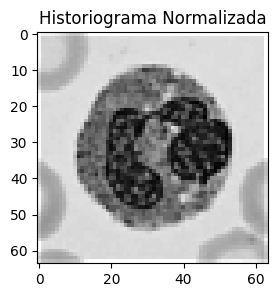

In [58]:


l = proc.unsharp_mask(img, conv_gauss )
plt.figure(figsize=(3, 3))
plt.imshow(l, cmap="gray")
plt.title("Historiograma Normalizada")
plt.show()


### Historiograma

In [59]:


    ## Testes


    #3Show one img

    #plt.figure(figsize=(3, 3))
    #plt.imshow(img_eq, cmap="gray")
    #plt.title("Historiograma Normalizada")
    #plt.show()



    #point_start, point_count = metricas.hist(img)
    #draw_hist(point_start, point_count)
    #plt.title("Histograma Orginal")
    #plt.show()

    ### Normalizaco historigrama pelo cv2
    #img_eq_cv2 = cv2.equalizeHist(n_img)

    #plt.figure(figsize=(3, 3))
    #plt.imshow(img_eq_cv2, cmap="gray")
    #plt.title("Resultado cv2.equalizeHist()")
    #plt.show()
    #point_start, point_count = metricas.hist(img_eq_cv2)
    #draw_hist(point_start, point_count)
    #plt.title("Histograma  cv2.equalizeHist()")
    #plt.show()

